# **Line, Circle and Blob Detection**

## **Objectives:**
1. Houghlines
2. Probabilistic Houghlines
3. Hough Circles
4. Blob Detection

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Line Detection - Using Hough Lines**
   
The Hough transform takes a binary edge map as input and attempts to locate edges placed as straight lines. The idea of the Hough transform is, that every edge point in the edge map is transformed to all possible lines that could pass through that point.

`cv2.HoughLines(binarized/thresholded image, 𝜌 accuracy, 𝜃 accuracy, threshold)`
- Threshold here is the minimum vote for it to be considered a line


### The core trick: turn "find a line" into "find a crossing point"

A line can be written as `ρ = x·cosθ + y·sinθ`, where `ρ` is the line's distance from the origin and `θ` its angle — instead of the usual `y = mx + b` (which breaks down for vertical lines; `ρ, θ` doesn't).

Here's the move that makes Hough transform work: **fix a single edge point** `(x, y)` and ask *every possible line through it* — sweep `θ` from 0 to 180° and compute the `ρ` each angle needs. That traces out a sine-wave curve in `(θ, ρ)` space. One image point → one curve in parameter space.

Now do that for *every* edge point. If three edge points happen to be genuinely collinear — sitting on the same real line — their three sine curves all cross at the *exact same* `(θ, ρ)`, because that one `(θ, ρ)` pair describes a line every one of them lies on. Points that *aren't* collinear produce curves that cross randomly, spreading their votes thin. So "find the line" becomes "find the `(θ, ρ)` cell with the most curves crossing through it" — literally counting votes in an accumulator array, which is exactly what the `threshold` parameter in `cv2.HoughLines` is a minimum vote count for. See it directly:

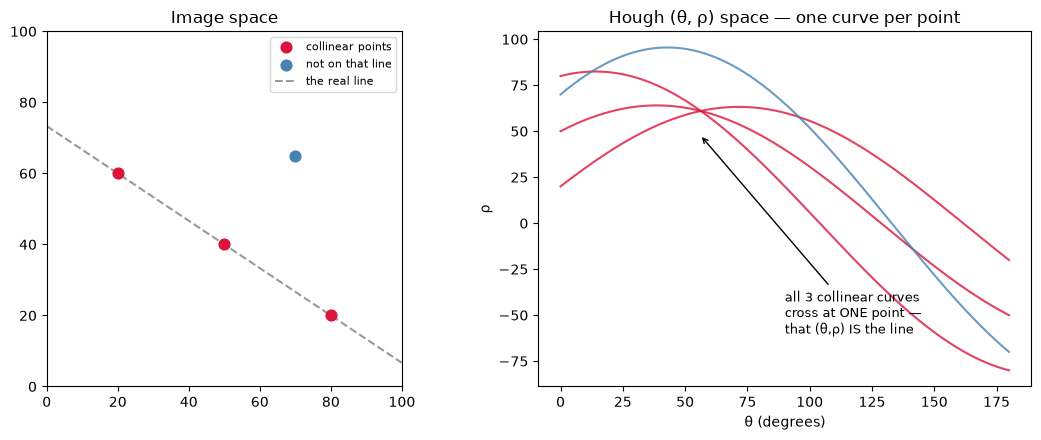

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 3 points on one real line, plus 1 point that is NOT on that line
on_line = [(20, 60), (50, 40), (80, 20)]     # y = -2/3 x + 73.3, roughly
off_line = [(70, 65)]

thetas = np.linspace(0, np.pi, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].set_title('Image space')
xs, ys = zip(*on_line)
axes[0].scatter(xs, ys, color='crimson', s=60, label='collinear points', zorder=3)
xs2, ys2 = zip(*off_line)
axes[0].scatter(xs2, ys2, color='steelblue', s=60, label='not on that line', zorder=3)
xx = np.linspace(0, 100, 10)
m, b = (on_line[-1][1]-on_line[0][1])/(on_line[-1][0]-on_line[0][0]), on_line[0][1]
axes[0].plot(xx, b + m*(xx-on_line[0][0]), 'k--', alpha=0.4, label='the real line')
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100); axes[0].legend(fontsize=8); axes[0].set_aspect('equal')

axes[1].set_title('Hough (θ, ρ) space — one curve per point')
for (x, y), color in zip(on_line, ['crimson']*3):
    rho = x*np.cos(thetas) + y*np.sin(thetas)
    axes[1].plot(np.degrees(thetas), rho, color=color, alpha=0.8)
for (x, y) in off_line:
    rho = x*np.cos(thetas) + y*np.sin(thetas)
    axes[1].plot(np.degrees(thetas), rho, color='steelblue', alpha=0.8)
axes[1].set_xlabel('θ (degrees)'); axes[1].set_ylabel('ρ')
axes[1].annotate('all 3 collinear curves\ncross at ONE point —\nthat (θ,ρ) IS the line',
                  xy=(56, 48), xytext=(90, -60),
                  arrowprops=dict(arrowstyle='->'), fontsize=9)
plt.tight_layout()
plt.show()

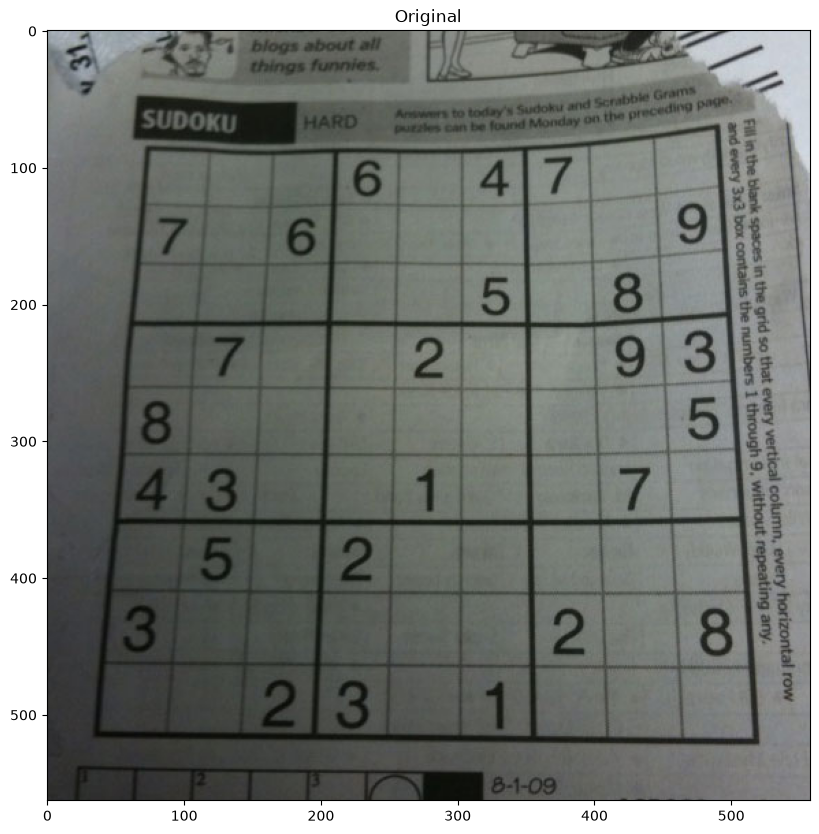

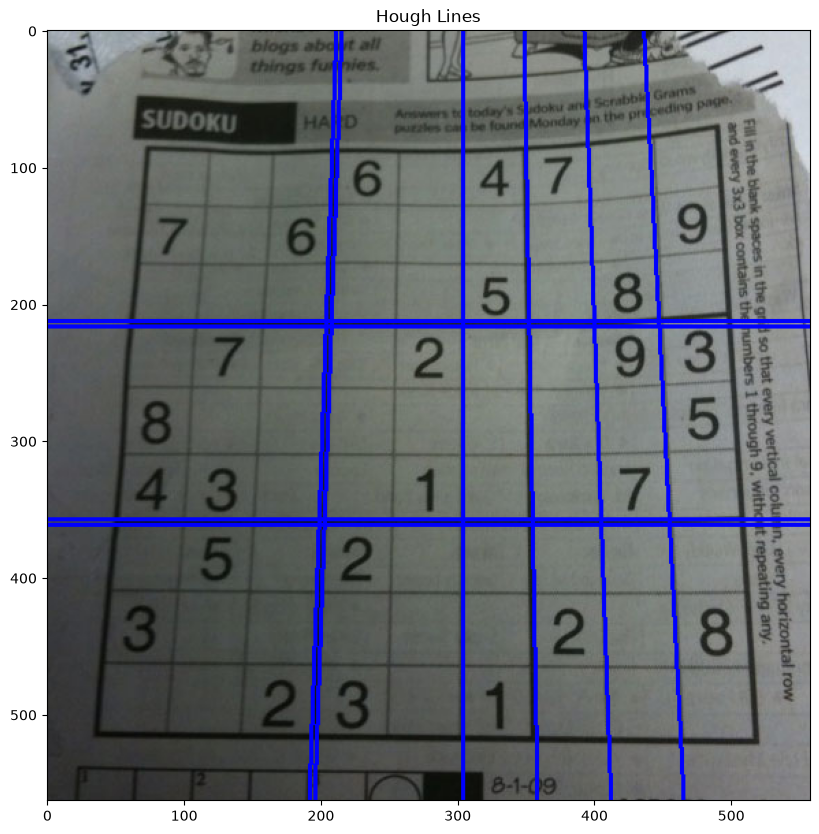

In [3]:
image = cv2.imread('assets/images/soduku.jpg')
imshow('Original', image)

# Grayscale and Canny Edges extracted
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 170, apertureSize = 3)

# Run HoughLines using a rho accuracy of 1 pixel
# theta accuracy of np.pi / 180 which is 1 degree
# Our line threshold is set to 240 (number of points on line)
lines = cv2.HoughLines(edges, 1, np.pi / 180, 240)

# We iterate through each line and convert it to the format
# required by cv2.lines (i.e. requiring end points)
for line in lines:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

imshow('Hough Lines', image)

## **Probabilistic Hough Lines**
A Hough Transform is considered probabilistic if it uses random sampling of the edge points. These algorithms can be divided based on how they map image space to parameter space.

```
cv2.HoughLinesP(binarized image, 𝜌 accuracy, 𝜃 accuracy, threshold, minimum line length, max line gap)
```

(74, 4)


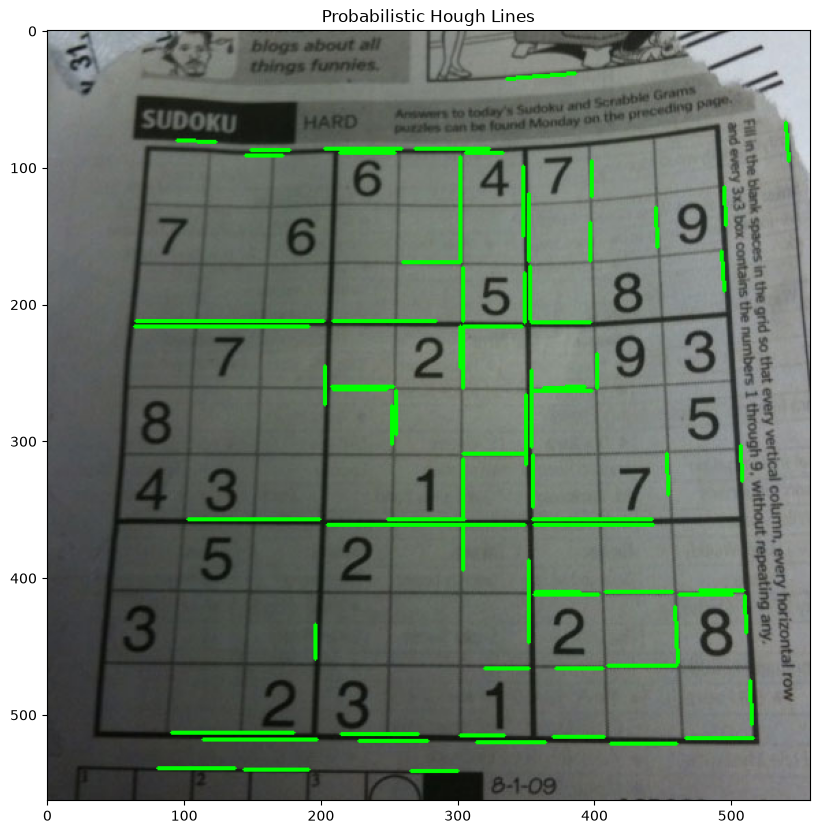

In [4]:
# Grayscale and Canny Edges extracted
image = cv2.imread('assets/images/soduku.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 170, apertureSize = 3)

# Again we use the same rho and theta accuracies
# However, we specific a minimum vote (pts along line) of 100
# and Min line length of 3 pixels and max gap between lines of 25 pixels
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, 3, 25)
# .reshape(-1, 4) normalizes across OpenCV versions — some return
# (N, 1, 4), others (N, 4) directly.
lines = lines.reshape(-1, 4)
print(lines.shape)

for x1, y1, x2, y2 in lines:
    cv2.line(image,(x1,y1),(x2,y2),(0,255,0),2)

imshow('Probabilistic Hough Lines', image)

## **Circle Detection - Hough Cirlces**

**cv2.HoughCircles**(image, method, dp, MinDist, param1, param2, minRadius, MaxRadius)


- Method - currently only cv2.HOUGH_GRADIENT available
- dp - Inverse ratio of accumulator resolution
- MinDist - the minimum distance between the center of detected circles
- param1 - Gradient value used in the edge detection
- param2 - Accumulator threshold for the HOUGH_GRADIENT method (lower allows more circles to be detected (false positives))
- minRadius - limits the smallest circle to this size (via radius)
- MaxRadius - similarly sets the limit for the largest circles

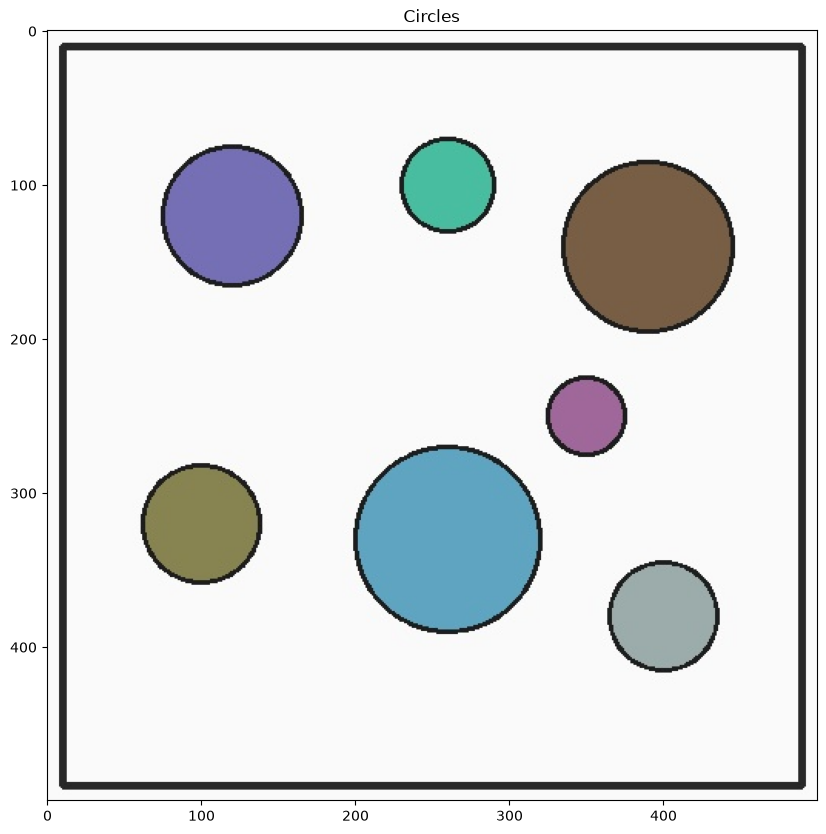

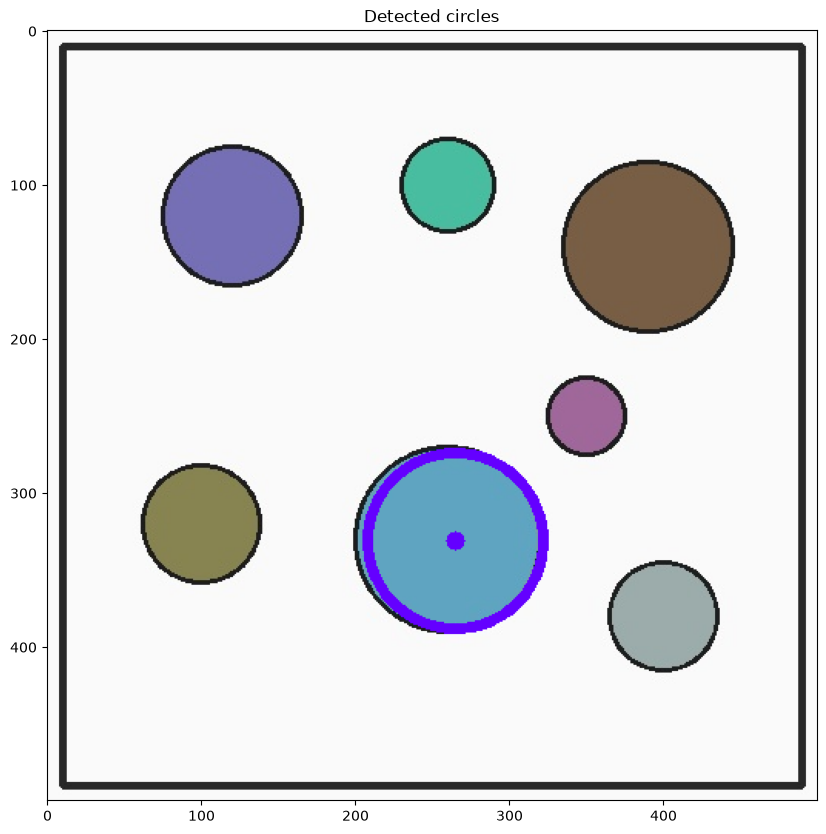

In [5]:
image = cv2.imread('./assets/images/Circles_In_Square.jpeg')
imshow('Circles', image)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.medianBlur(gray, 5)

circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, 1.2, 25)

cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1.2, 100)

circles = np.uint16(np.around(circles))

for i in circles[0,:]:
    # draw the outer circle
    cv2.circle(image,(i[0], i[1]), i[2], (255, 0, 100), 5)
    
    # draw the center of the circle
    cv2.circle(image, (i[0], i[1]), 2, (255, 0, 100), 8)

imshow('Detected circles', image)

## **Blob Detection**
The function **cv2.drawKeypoints** takes the following arguments:

**cv2.drawKeypoints**(input image, keypoints, blank_output_array, color, flags)

flags:
- cv2.DRAW_MATCHES_FLAGS_DEFAULT
- cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
- cv2.DRAW_MATCHES_FLAGS_DRAW_OVER_OUTIMG
- cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS

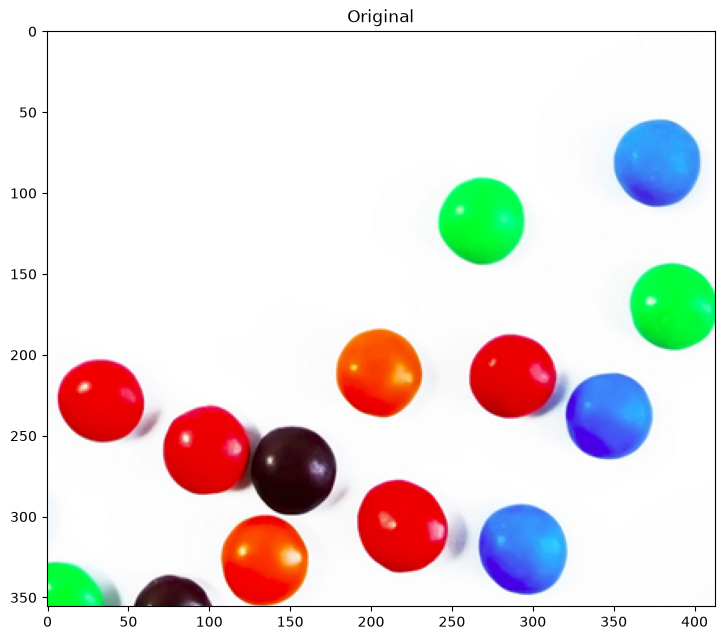

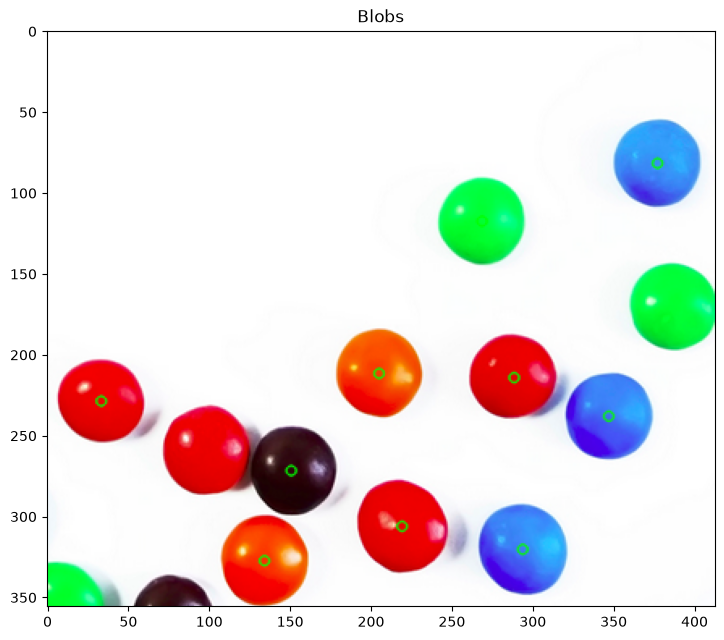

In [6]:
# Read image
image = cv2.imread("assets/images/Sunflowers.jpg")
imshow("Original", image)

# Set up the detector with default parameters.
detector = cv2.SimpleBlobDetector_create()
 
# Detect blobs.
keypoints = detector.detect(image)
 
# Draw detected blobs as red circles.
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ensures the size of
# the circle corresponds to the size of blob
blank = np.zeros((1,1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0,255,0),
                                      cv2.DRAW_MATCHES_FLAGS_DEFAULT)
 
# Show keypoints
imshow("Blobs", blobs)

### A couple of things worth poking at

- `cv2.HoughLinesP` (probabilistic) returns *segments*, not infinite lines — measure and print each detected segment's length on `images/soduku.jpg` with `np.hypot(x2-x1, y2-y1)`.
- Tighten `SimpleBlobDetector_Params` further: add `params.filterByColor = True; params.blobColor = 0` to keep only dark blobs on `images/smarties.png`'s bright background.